In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

sns.set_theme(style="whitegrid")

In [21]:
# 1. Load the dataset (Ensure 'titanic.csv' is in the same folder as your notebook)
df = pd.read_csv("C:\\Users\\lenovo\\OneDrive - Quaid-i-Azam University\\Desktop\\AI with python course\\second time\\Titanic-Dataset-Analysis-SVC\\titanic.csv")

# 2. Display the total number of rows and columns
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

# 3. Display the first 7 rows
df.head(7)

Total Rows: 418, Total Columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q


In [31]:
# 1. Descriptive statistics for numerical variables
print("--- Numerical Descriptive Statistics ---")
display(df.describe())

# 2. Identify and display numerical and categorical variables
num_cols = df.select_dtypes(include=['int64', 'float64', 'number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print("\nNumerical Variables:", num_cols)
print("Categorical Variables:", cat_cols)

# 3. Frequency distributions for 'Sex' and 'Pclass'
print("\n--- Sex Frequency Distribution ---")
print(df['Sex'].value_counts())

print("\n--- Pclass Frequency Distribution ---")
print(df['Pclass'].value_counts().sort_index())

--- Numerical Descriptive Statistics ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,1100.500000,0.363636,2.265550,29.599282,0.447368,0.392344,35.576535
std,120.810458,0.481622,0.841838,12.703770,0.896760,0.981429,55.850103
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,23.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,35.750000,1.000000,0.000000,31.471875
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200



Numerical Variables: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Variables: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

--- Sex Frequency Distribution ---
Sex
male      266
female    152
Name: count, dtype: int64

--- Pclass Frequency Distribution ---
Pclass
1    107
2     93
3    218
Name: count, dtype: int64


In [32]:
# 1. Count missing values in each column
print("--- Missing Values Count ---")
print(df.isnull().sum())

# 2. Fill numerical missing values with median
if 'Age' in df.columns and df['Age'].isnull().sum() > 0:
    df['Age'] = df['Age'].fillna(df['Age'].median())

if 'Fare' in df.columns and df['Fare'].isnull().sum() > 0:
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Fill any remaining numerical nulls
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical missing values (if any) with mode
if 'Embarked' in df.columns and df['Embarked'].isnull().sum() > 0:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Verify missing values are handled
print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())

--- Missing Values Count ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64

--- Missing Values After Cleaning ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


In [34]:
# 1. Prepare copy for modeling and encode 'Sex'
from sklearn.preprocessing import StandardScaler


from sklearn.preprocessing import StandardScaler


df_model = df.copy()
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})

# Define features (X) and target variable (y)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df_model[features]
y = df_model['Survived']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Apply Feature Scaling (CRITICAL FOR SVC)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Build and train Support Vector Classifier
model = SVC(kernel='rbf', C=1.0, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# 5. Calculate Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\n--- Confusion Matrix ---")
print(cm)

Accuracy:  0.9762
Precision: 0.9677
Recall:    0.9677
F1-Score:  0.9677

--- Confusion Matrix ---
[[52  1]
 [ 1 30]]


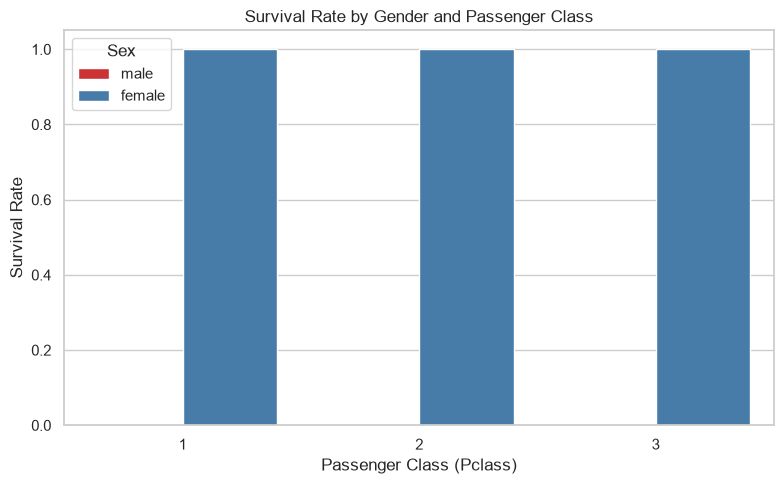

In [35]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', errorbar=None, palette='Set1')
plt.title('Survival Rate by Gender and Passenger Class')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Survival Rate')
plt.ylim(0, 1.05)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

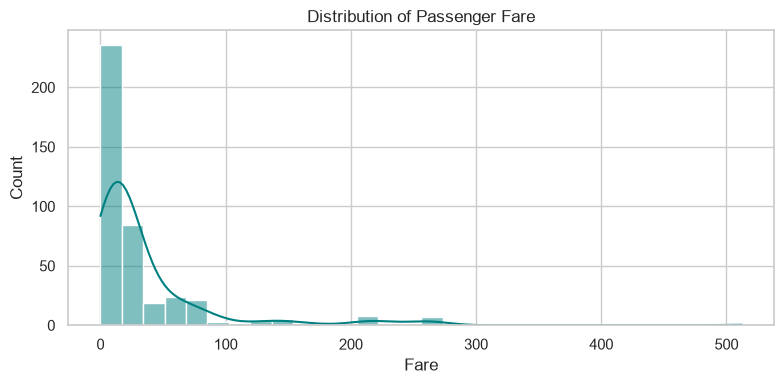

In [36]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Fare'], kde=True, bins=30, color='teal')
plt.title('Distribution of Passenger Fare')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

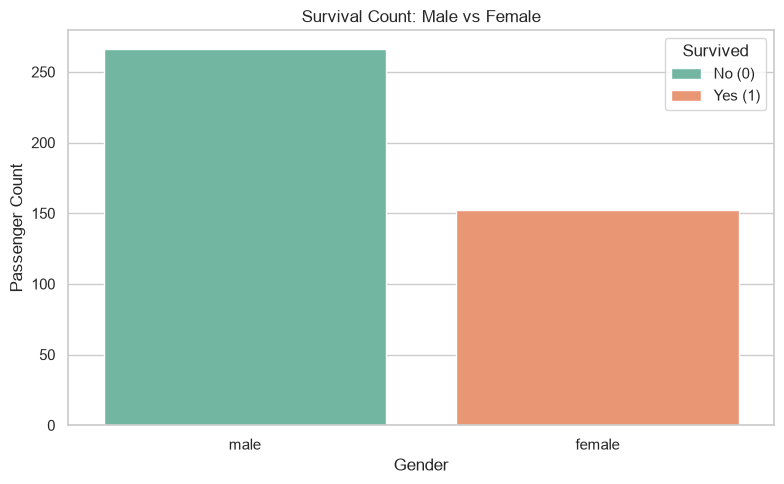

Analysis: Female survival rate was 100.00%, significantly higher than male survival rate (0.00%).


In [37]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sex', hue='Survived', palette='Set2')
plt.title('Survival Count: Male vs Female')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

# Printed summary
female_surv = (df[df['Sex'] == 'female']['Survived'] == 1).mean() * 100
male_surv = (df[df['Sex'] == 'male']['Survived'] == 1).mean() * 100
print(f"Analysis: Female survival rate was {female_surv:.2f}%, significantly higher than male survival rate ({male_surv:.2f}%).")